## Build Basic Graph with LangGraph

#### State

The state schema serves as the input schema for all nodes and edges in the graph

In [2]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info:str

### Nodes
Nodes are Python functions with first positional argument is state, as defined above.

Because the state is a TypedDict, each node can access the graph_state key as state['graph_state'].

Each node returns a new value for graph_state key. By default, it will override the prior state value.

In [3]:
def start_cooking(state:State):
    print("start_cooking node is called")
    return {"graph_info":state['graph_info'] + " I am starting cooking"}

def pizza(state:State):
    print("pizza node is called")
    return {"graph_info":state['graph_info'] + " pizza"}

def biryani(state:State):
    print("biryani node is called")
    return {"graph_info":state['graph_info'] + " biryani"}

In [4]:
import random
from typing import Literal

def trial_cooking(state:State)-> Literal['pizza','biryani']:
    graph_info=state['graph_info']

    if random.random()>0.5:
        return "pizza"
    else:
        return "biryani"

### Graph Construction

First, initialize a StateGraph with the State class defined above then add nodes and edges.

START Node is a special node that sends user input to the graph to indicate where to start our graph.

END Node is a special node that represents a termination node.

Finally, compile graph to perform basic checks and visualize the graph as a Mermaid diagram.

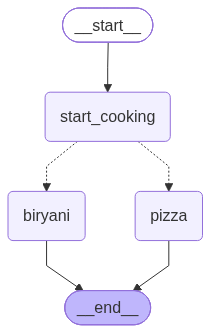

In [5]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

## Build Graph
graph=StateGraph(State)

### Add Nodes
graph.add_node("start_cooking", start_cooking)
graph.add_node("pizza", pizza)
graph.add_node("biryani", biryani)

### Build Graph flow

graph.add_edge(START, "start_cooking")
graph.add_conditional_edges("start_cooking", trial_cooking)
graph.add_edge("pizza", END)
graph.add_edge("biryani", END)

## Compile Graph
graph_builder=graph.compile()

## View Graph Flow
display(Image(graph_builder.get_graph().draw_mermaid_png()))


### Graph Invocation

In [13]:
graph_builder.invoke({"graph_info":"Cooking graph flow invoked,"})

start_cooking node is called
biryani node is called


{'graph_info': 'Cooking graph flow invoked, I am starting cooking biryani'}